# Comparando SVD x PCA x KPCA

## Importações

In [ ]:
!pip install optuna

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
import optuna
import logging
from sklearn.decomposition import PCA, TruncatedSVD, KernelPCA
from sklearn.metrics import mean_squared_error
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from tensorflow.keras.datasets import fashion_mnist

## Preparando o dataset

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("1. Carregando dados e aplicando ruído...")
(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_full = np.concatenate((x_train, x_test), axis=0) / 255.0
x_flat = x_full.reshape((x_full.shape[0], 784))

noise_factor = 0.2
x_noisy = np.clip(x_flat + noise_factor * np.random.normal(0.0, 1.0, x_flat.shape), 0., 1.)

limite_optuna, limite_teste = 2000, 10000
x_noisy_opt, x_clean_opt = x_noisy[:limite_optuna], x_flat[:limite_optuna]
x_noisy_test, x_clean_test = x_noisy[:limite_teste], x_flat[:limite_teste]

# Função auxiliar para calcular SSIM em lote
def calc_ssim_batch(clean, rec):
    return np.mean([ssim(clean[i].reshape(28,28), rec[i].reshape(28,28), data_range=1.0) for i in range(len(clean))])

1. Carregando dados e aplicando ruído...


## Otimização com Optuna

O objetivo é encontrar os melhores hiperparâmetros, com um subconjunto (2.000 amostras) dos dados, para depois aplicá-los no conjunto total. A otimização foi feita para o PCA e KPCA, o SVD usará o mesmo resultado do PCA.

In [ ]:
print("\n" + "="*60 + "\n FASE 1: OTIMIZAÇÃO DUPLA (MSE e SSIM) - 20 Trials Cada\n" + "="*60)

# --- 1. Otimização PCA ---
def obj_pca_mse(trial):
    pca = PCA(n_components=trial.suggest_int('n_components', 20, 200))
    return mean_squared_error(x_clean_opt, pca.inverse_transform(pca.fit_transform(x_noisy_opt)))

def obj_pca_ssim(trial):
    pca = PCA(n_components=trial.suggest_int('n_components', 20, 200))
    return calc_ssim_batch(x_clean_opt, pca.inverse_transform(pca.fit_transform(x_noisy_opt)))

study_pca_mse = optuna.create_study(direction='minimize')
study_pca_mse.optimize(obj_pca_mse, n_trials=20)

study_pca_ssim = optuna.create_study(direction='maximize')
study_pca_ssim.optimize(obj_pca_ssim, n_trials=20)

# --- 2. Otimização SVD ---
def obj_svd_mse(trial):
    svd = TruncatedSVD(n_components=trial.suggest_int('n_components', 20, 200))
    return mean_squared_error(x_clean_opt, svd.inverse_transform(svd.fit_transform(x_noisy_opt)))

def obj_svd_ssim(trial):
    svd = TruncatedSVD(n_components=trial.suggest_int('n_components', 20, 200))
    return calc_ssim_batch(x_clean_opt, svd.inverse_transform(svd.fit_transform(x_noisy_opt)))

study_svd_mse = optuna.create_study(direction='minimize')
study_svd_mse.optimize(obj_svd_mse, n_trials=20)

study_svd_ssim = optuna.create_study(direction='maximize')
study_svd_ssim.optimize(obj_svd_ssim, n_trials=20)

# --- 3. Otimização KPCA ---
def get_kpca_params(trial):
    p = {'n_components': trial.suggest_int('n_components', 20, 200),
         'kernel': trial.suggest_categorical('kernel', ['rbf', 'poly']),
         'gamma': trial.suggest_float('gamma', 1e-4, 1e-1, log=True)}
    if p['kernel'] == 'poly':
        p['degree'] = trial.suggest_int('degree', 2, 4)
        p['coef0'] = trial.suggest_float('coef0', 0.0, 5.0)
    return p

def obj_kpca_mse(trial):
    kpca = KernelPCA(**get_kpca_params(trial), fit_inverse_transform=True)
    return mean_squared_error(x_clean_opt, kpca.inverse_transform(kpca.fit_transform(x_noisy_opt)))

def obj_kpca_ssim(trial):
    kpca = KernelPCA(**get_kpca_params(trial), fit_inverse_transform=True)
    return calc_ssim_batch(x_clean_opt, kpca.inverse_transform(kpca.fit_transform(x_noisy_opt)))

study_kpca_mse = optuna.create_study(direction='minimize')
study_kpca_mse.optimize(obj_kpca_mse, n_trials=20)

study_kpca_ssim = optuna.create_study(direction='maximize')
study_kpca_ssim.optimize(obj_kpca_ssim, n_trials=20)

print("\n-> FASE 1 Concluída! Melhores Hiperparâmetros Encontrados:")
print(f"PCA (MSE):  {study_pca_mse.best_params}")
print(f"PCA (SSIM): {study_pca_ssim.best_params}")
print(f"SVD (MSE):  {study_svd_mse.best_params}")
print(f"SVD (SSIM): {study_svd_ssim.best_params}")
print(f"KPCA (MSE):  {study_kpca_mse.best_params}")
print(f"KPCA (SSIM): {study_kpca_ssim.best_params}")


 FASE 1: OTIMIZAÇÃO DUPLA (MSE e SSIM) - 20 Trials Cada

-> FASE 1 Concluída! Melhores Hiperparâmetros Encontrados:
PCA (MSE):  {'n_components': 101}
PCA (SSIM): {'n_components': 122}
SVD (MSE):  {'n_components': 90}
SVD (SSIM): {'n_components': 126}
KPCA (MSE):  {'n_components': 46, 'kernel': 'poly', 'gamma': 0.01745721103568016, 'degree': 3, 'coef0': 2.3063765797853457}
KPCA (SSIM): {'n_components': 127, 'kernel': 'poly', 'gamma': 0.02664042723518366, 'degree': 2, 'coef0': 3.5972585013048533}


## Aplicação dos hiperparâmetros

In [ ]:
print("\n" + "="*60 + "\n FASE 2: AVALIAÇÃO FINAL E MÉTRICAS (10000 AMOSTRAS)\n" + "="*60)

# Dicionário com os 6 modelos otimizados
modelos = {
    'PCA (Otimizado p/ MSE)': PCA(n_components=study_pca_mse.best_params['n_components']),
    'PCA (Otimizado p/ SSIM)': PCA(n_components=study_pca_ssim.best_params['n_components']),
    'SVD (Otimizado p/ MSE)': TruncatedSVD(n_components=study_svd_mse.best_params['n_components']),
    'SVD (Otimizado p/ SSIM)': TruncatedSVD(n_components=study_svd_ssim.best_params['n_components']),
    'KPCA (Otimizado p/ MSE)': KernelPCA(**study_kpca_mse.best_params, fit_inverse_transform=True),
    'KPCA (Otimizado p/ SSIM)': KernelPCA(**study_kpca_ssim.best_params, fit_inverse_transform=True)
}

resultados = {}

for nome, modelo in modelos.items():
    start = time.time()
    # Ajuste e reconstrução da imagem
    rec = modelo.inverse_transform(modelo.fit_transform(x_noisy_test))
    tempo_exec = time.time() - start

    # Cálculo das métricas globais para a base de 10.000 imagens
    mse_val = mean_squared_error(x_clean_test, rec)
    psnr_vals = [psnr(x_clean_test[i].reshape(28,28), rec[i].reshape(28,28), data_range=1.0) for i in range(limite_teste)]
    ssim_vals = [ssim(x_clean_test[i].reshape(28,28), rec[i].reshape(28,28), data_range=1.0) for i in range(limite_teste)]

    psnr_medio = np.mean(psnr_vals)
    ssim_medio = np.mean(ssim_vals)

    resultados[nome] = {'dados': rec, 'tempo': tempo_exec, 'mse': mse_val, 'psnr': psnr_medio, 'ssim': ssim_medio}

    # Log no terminal
    print(f"{nome}:")
    print(f"  - Tempo Execução: {tempo_exec:.4f}s")
    print(f"  - MSE Global: {mse_val:.5f}")
    print(f"  - PSNR Médio: {psnr_medio:.2f} dB")
    print(f"  - SSIM Médio: {ssim_medio:.4f}\n")


 FASE 2: AVALIAÇÃO FINAL E MÉTRICAS (10000 AMOSTRAS)
PCA (Otimizado p/ MSE):
  - Tempo Execução: 0.5762s
  - MSE Global: 0.01464
  - PSNR Médio: 18.55 dB
  - SSIM Médio: 0.6193

PCA (Otimizado p/ SSIM):
  - Tempo Execução: 0.5471s
  - MSE Global: 0.01444
  - PSNR Médio: 18.58 dB
  - SSIM Médio: 0.6227

SVD (Otimizado p/ MSE):
  - Tempo Execução: 2.3143s
  - MSE Global: 0.01496
  - PSNR Médio: 18.48 dB
  - SSIM Médio: 0.6143

SVD (Otimizado p/ SSIM):
  - Tempo Execução: 2.2443s
  - MSE Global: 0.01459
  - PSNR Médio: 18.53 dB
  - SSIM Médio: 0.6205

KPCA (Otimizado p/ MSE):
  - Tempo Execução: 210.1785s
  - MSE Global: 0.01472
  - PSNR Médio: 18.57 dB
  - SSIM Médio: 0.6030

KPCA (Otimizado p/ SSIM):
  - Tempo Execução: 200.5656s
  - MSE Global: 0.01330
  - PSNR Médio: 18.91 dB
  - SSIM Médio: 0.6311



## Resultados visuais

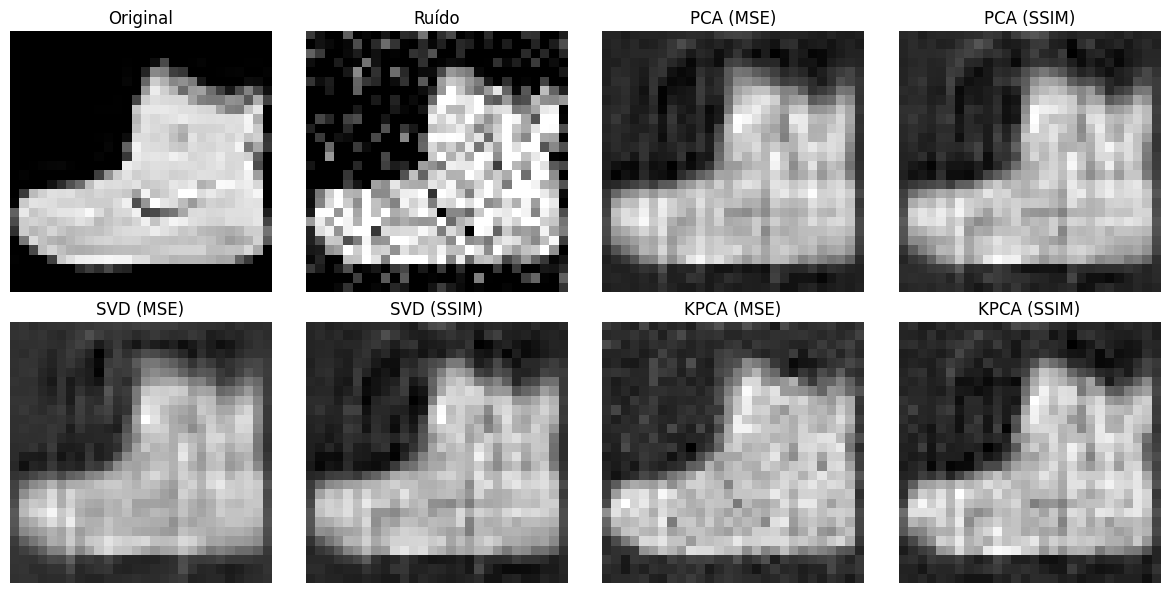

In [ ]:
idx = 0
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

titulos = ['Original', 'Ruído', 'PCA (MSE)', 'PCA (SSIM)',
           'SVD (MSE)', 'SVD (SSIM)', 'KPCA (MSE)', 'KPCA (SSIM)']

imagens = [x_clean_test[idx], x_noisy_test[idx],
           resultados['PCA (Otimizado p/ MSE)']['dados'][idx], resultados['PCA (Otimizado p/ SSIM)']['dados'][idx],
           resultados['SVD (Otimizado p/ MSE)']['dados'][idx], resultados['SVD (Otimizado p/ SSIM)']['dados'][idx],
           resultados['KPCA (Otimizado p/ MSE)']['dados'][idx], resultados['KPCA (Otimizado p/ SSIM)']['dados'][idx]]

for i, ax in enumerate(axes):
    ax.imshow(imagens[i].reshape(28, 28), cmap='gray')
    ax.set_title(titulos[i], fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.savefig("reconstrucao_comparativa.png", dpi=300, bbox_inches='tight')
plt.show()